In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.tsa.stattools import adfuller
import yfinance as yf

# Moving Average Crossover Strategy (SMA)

<br>
<div class="alert alert-block alert-info"><b>
For the first algorithmic trading strategy we will use the Simple Moving Average (SMA), which is generally considered the
entry point but is also used in more advanced strategies as well as machine learning and advanced time series forecasting
methods. We will use the Dow Jones portfolio from yfinance and will generate buy and sell signals and as usual we will evaluate
other models and their metrics as well.
</b></div>
</br>

In [2]:
df = yf.Ticker('^DJI')
df1 = df.history(start = '2025-01-02')[['Close']]
df1.copy()
df1.head()

,Close
Date,
2025-01-02 00:00:00-05:00,42392.269531
2025-01-03 00:00:00-05:00,42732.128906
2025-01-06 00:00:00-05:00,42706.558594
2025-01-07 00:00:00-05:00,42528.359375
2025-01-08 00:00:00-05:00,42635.199219


<br>
<div class="alert alert-block alert-info"><b>
Above we load in the data from yfinance and set the starting date to 02 January 2025, cannot be the first day of January as that
is a public holiday which is a non-trading day. We use a longer time frame for this project because Crossover Strategies that use
the SMA follow trends and require a longer period to capture those trends. Below we calculate the log transform and we difference
our data - we then shift the Log Returns column backwards by 1 row so that the data lines up with the Close column. Computing the log
transform and differencing the data is also used in making time series stationary - in this case we need the Log Returns because we
are hypothetically trading and are interested in the Returns not the Actual values.
</b></div>
</br>

In [3]:
df1['LogReturns'] = np.log(df1['Close']).diff()
df1['LogReturns'] = df1['LogReturns'].shift(-1)
df1.head()

,Close,LogReturns
Date,,
2025-01-02 00:00:00-05:00,42392.269531,0.007985
2025-01-03 00:00:00-05:00,42732.128906,-0.000599
2025-01-06 00:00:00-05:00,42706.558594,-0.004181
2025-01-07 00:00:00-05:00,42528.359375,0.002509
2025-01-08 00:00:00-05:00,42635.199219,-0.016477


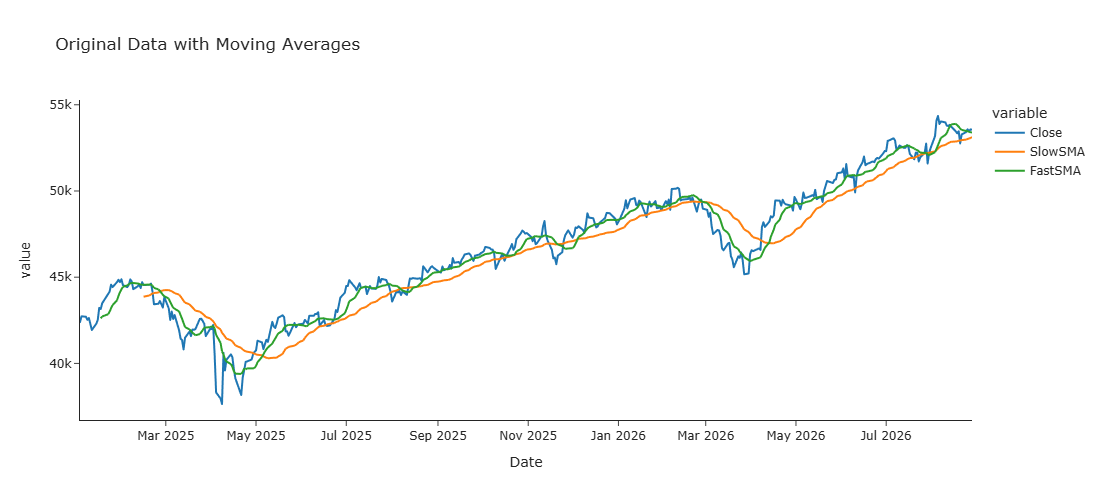

In [28]:
df1['SlowSMA'] = df1['Close'].rolling(30).mean()
df1['FastSMA'] = df1['Close'].rolling(10).mean()

fig = px.line(df1, x = df1.index, y = ['Close', 'SlowSMA', 'FastSMA'],
             height = 500, width = 1000, template = 'simple_white', title = 'Original Data with Moving Averages')
fig.show()
fig.write_html('my_plot.html')

<br>
<div class="alert alert-block alert-info"><b>
In the plot above we show the FastSMA which has a rolling window of 10 days (lags) and the SlowSMA with a window of 30 days (lags),
we can see that the FastSMA captures the peaks and troughs of the data much closer, whereas the SlowSMA shows a much smoother time
series. When these two windows cross over one another we will generate buy and sell signals. When the FastSMA is less than the SlowSMA
but crosses in an upward direction we will Buy and Sell when it moves in the opposite direction.
</b></div>
</br>

In [5]:
df1['Signal'] = np.where(df1['FastSMA'] >= df1['SlowSMA'], 1, 0)
df1.iloc[80:].head(10)

,Close,LogReturns,SlowSMA,FastSMA,Signal
Date,,,,,
2025-04-30 00:00:00-04:00,40669.359375,0.002054,40560.571745,39740.705078,0
2025-05-01 00:00:00-04:00,40752.960938,0.013756,40520.182813,39849.062109,0
2025-05-02 00:00:00-04:00,41317.429688,-0.002389,40498.986458,40066.582031,0
2025-05-05 00:00:00-04:00,41218.828125,-0.009503,40473.435677,40371.423828,0
2025-05-06 00:00:00-04:00,40829.000000,0.006955,40414.958333,40535.625781,1
2025-05-07 00:00:00-04:00,41113.968750,0.006171,40365.840625,40686.365625,1
2025-05-08 00:00:00-04:00,41368.449219,-0.002882,40329.629297,40813.870703,1
2025-05-09 00:00:00-04:00,41249.378906,0.027751,40294.618620,40927.458594,1
2025-05-12 00:00:00-04:00,42410.101562,-0.006379,40322.158724,41145.709766,1


In [6]:
df1['PrevSignal'] = df1['Signal'].shift(1)
df1['Buy'] = (df1['PrevSignal'] == 0) & (df1['Signal'] == 1)
df1['Sell'] = (df1['PrevSignal'] == 1) & (df1['Signal'] == 0)

df1.iloc[80:].head(10)

,Close,LogReturns,SlowSMA,FastSMA,Signal,PrevSignal,Buy,Sell
Date,,,,,,,,
2025-04-30 00:00:00-04:00,40669.359375,0.002054,40560.571745,39740.705078,0,0.0,False,False
2025-05-01 00:00:00-04:00,40752.960938,0.013756,40520.182813,39849.062109,0,0.0,False,False
2025-05-02 00:00:00-04:00,41317.429688,-0.002389,40498.986458,40066.582031,0,0.0,False,False
2025-05-05 00:00:00-04:00,41218.828125,-0.009503,40473.435677,40371.423828,0,0.0,False,False
2025-05-06 00:00:00-04:00,40829.000000,0.006955,40414.958333,40535.625781,1,0.0,True,False
2025-05-07 00:00:00-04:00,41113.968750,0.006171,40365.840625,40686.365625,1,1.0,False,False
2025-05-08 00:00:00-04:00,41368.449219,-0.002882,40329.629297,40813.870703,1,1.0,False,False
2025-05-09 00:00:00-04:00,41249.378906,0.027751,40294.618620,40927.458594,1,1.0,False,False
2025-05-12 00:00:00-04:00,42410.101562,-0.006379,40322.158724,41145.709766,1,1.0,False,False


<br>
<div class="alert alert-block alert-info"><b>
In the code above we create a Signal column, as well as a Previous Signal column which is just the Signal column shifted
forwards by 1 row. This allows us to create the Buy and Sell signals because we can see when the data crosses one another.
<br></br>
In the code cells below we define a function that will determine for each step/day whether we are invested or not. The first IF
statement sets the IsInvested column to False if we are already invested and the Sell column is 1/True - means we are selling and
will no longer be invested. The second IF statement sets the IsInvested column to True if we are not invested and the Buy column is
1/True as this signals we will Buy and become invested.
</b</div>
</br>

In [7]:
is_invested = False

def assign_is_invested(row):
    global is_invested

    if is_invested and row['Sell']:
        is_invested = False

    if not is_invested and row['Buy']:
        is_invested = True

    return is_invested

df1['IsInvested'] = df1.apply(assign_is_invested, axis = 1)

In [8]:
df1['AlgoReturns'] = df1['IsInvested'] * df1['LogReturns']
print('Algorithm Returns:', df1['AlgoReturns'].sum())
print('Buy-and_Hold Returns:', df1['LogReturns'].sum())

Algorithm Returns: 0.15704994246512705
Buy-and_Hold Returns: 0.2338362787872832


<br>
<div class="alert alert-block alert-info"><b>
Above we calculate the percentage of the Strategies Returns and the Buy-and-Hold Returns - we get about 16% and 23% respectively.
This shows that the Buy-and-Hold Strategy performs slightly better. 
<br></br>
In the code cells below we calculate the Standard Deviation and the Sharpe Ratio for the two strategies. The Risk Free Rate is the
return of and investment with zero loss, these tend to be financial instruments like long and short term government bonds. Obtained
the Risk Free Rate from the internet and will divide it by 252 as this is generally the amount of trading days within a given year,
as we are working with data that has a daily frequency. The Standard Deviation measures the variance or volatility of our strategies
and we can see that our Algorithm Strategy has less volatility or risk compared to the Buy-and_Hold strategy. The Sharpe Ratio is the
excess returns measured against the risk/volatility of the investment, both strategies are under 1 which is not that great but the
Buy-and-Hold strategy is the better option for returns even though the risk is also slightly higher.
</b></div>
</br>

In [9]:
risk_free_rate = 0.043 / 252

print('Standard Deviation:', df1['AlgoReturns'].std())
print('Sharpe Ratio:', (df1['AlgoReturns'].mean() - risk_free_rate) / df1['AlgoReturns'].std())

Standard Deviation: 0.0062112070084447265
Sharpe Ratio: 0.03360260995892553


In [10]:
print('Standard Deviation:', df1['LogReturns'].std())
print('Sharpe Ratio:', (df1['LogReturns'].mean() - risk_free_rate) / df1['LogReturns'].std())

Standard Deviation: 0.009722045872177771
Sharpe Ratio: 0.04054568492944811


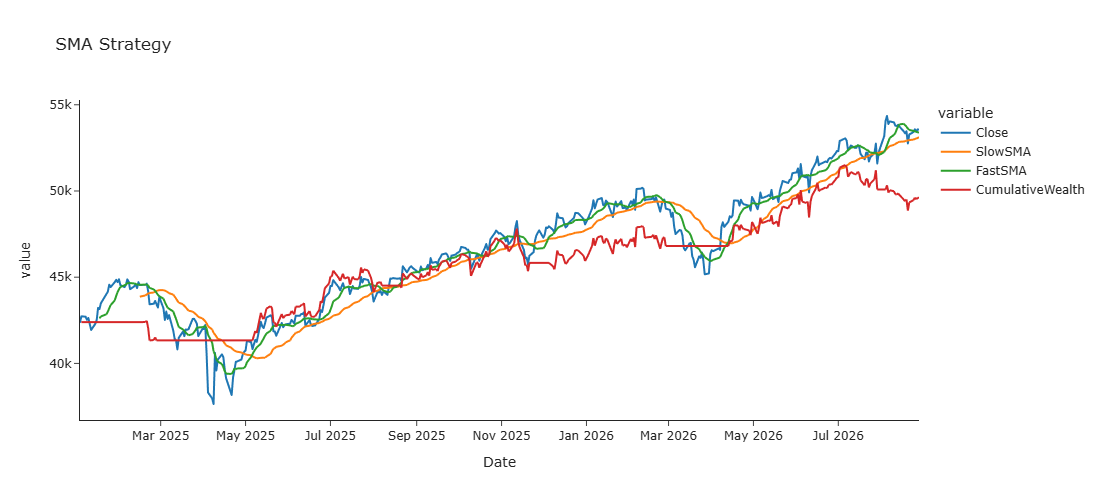

In [11]:
df1['CumulativeReturns'] = df1['AlgoReturns'].cumsum().shift(1)
df1['CumulativeWealth'] = df1.iloc[0]['Close'] * np.exp(df1['CumulativeReturns'])

fig = px.line(df1, x = df1.index, y = ['Close', 'SlowSMA', 'FastSMA', 'CumulativeWealth'],
             height = 500, width = 1000, template = 'simple_white', title = 'SMA Strategy')
fig.show()

<br>
<div class="alert alert-block alert-info"><b>
In the plot above we calculate the Cumulative Returns of the Algorithm and shift it forwards by 1 step as earlier we shifted
backwards by 1 step due the differencing of the data. The Cumulative Wealth column is the initial price of the data multiplied
by the exponential of the Cumulative Returns - exponentiating will return the inverse of the log transform. The Cumulative Wealth
plot has straight horizontal lines - each end point of the horizontal line should indicate where the buy and sell signals are. Plotly
is interactive and thankfully has a zoom function. We can see that in this plot our Algorithm does not react fast enough to the cross
overs and does not buy and sell during the correct crossovers, but is a baseline to work off of and compare with other strategies.
</b></div>
</br>

# Exponential Moving Average Crossover Strategy (EMA)

<br>
<div class="alert alert-block alert-info"><b>
Next we will explore using a Weighted Moving Average Strategy (EMA) as this type of time series technique assigns weight
to more recent price trends/changes and so we hope that this strategy will react faster and can capture the Buy and Sell
signals better compared to the SMA.
<br></br>
In the code cells below, everything is the same as before expect for the use of the EWM rolling window. We can see that
these averages are a little bit closer to the orginal data and are slightly less smooth. We can also see that the EMA
captures the data from start to the end points as it does not lag in the same manner that the SMA does.
</b></div>
</br>

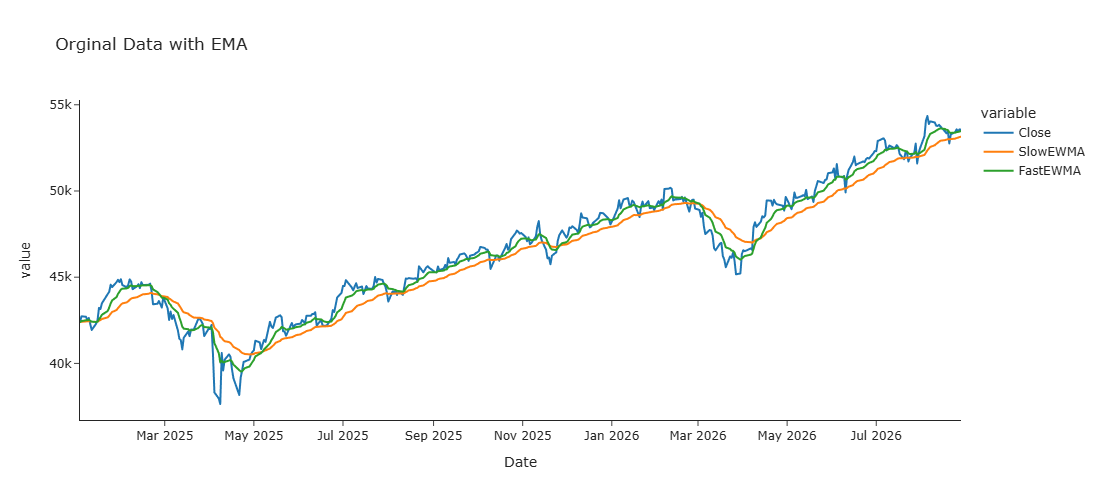

In [12]:
df2 = df1[['Close']].copy()
df2['SlowEWMA'] = df1['Close'].ewm(span = 30, adjust = False).mean()
df2['FastEWMA'] = df1['Close'].ewm(span = 10, adjust = False).mean()

fig = px.line(df2, x = df2.index, y = ['Close', 'SlowEWMA', 'FastEWMA'],
             height = 500, width = 1000, template = 'simple_white', title = 'Orginal Data with EMA')
fig.show()

In [13]:
df2['Signal2'] = np.where(df2['FastEWMA'] >= df2['SlowEWMA'], 1, 0)
df2.iloc[80:].head(10)

,Close,SlowEWMA,FastEWMA,Signal2
Date,,,,
2025-04-30 00:00:00-04:00,40669.359375,40533.495665,40080.513048,0
2025-05-01 00:00:00-04:00,40752.960938,40547.654715,40202.776300,0
2025-05-02 00:00:00-04:00,41317.429688,40597.317617,40405.440552,0
2025-05-05 00:00:00-04:00,41218.828125,40637.415069,40553.329202,0
2025-05-06 00:00:00-04:00,40829.000000,40649.775387,40603.451165,0
2025-05-07 00:00:00-04:00,41113.968750,40679.723346,40696.272544,1
2025-05-08 00:00:00-04:00,41368.449219,40724.157273,40818.486485,1
2025-05-09 00:00:00-04:00,41249.378906,40758.042540,40896.830562,1
2025-05-12 00:00:00-04:00,42410.101562,40864.626993,41171.970744,1


In [14]:
df2['PrevSignal2'] = df2['Signal2'].shift(1)
df2['Buy2'] = (df2['PrevSignal2'] == 0) & (df2['Signal2'] == 1)
df2['Sell2'] = (df2['PrevSignal2'] == 1) & (df2['Signal2'] == 0)

df2.iloc[80:].head(10)

,Close,SlowEWMA,FastEWMA,Signal2,PrevSignal2,Buy2,Sell2
Date,,,,,,,
2025-04-30 00:00:00-04:00,40669.359375,40533.495665,40080.513048,0,0.0,False,False
2025-05-01 00:00:00-04:00,40752.960938,40547.654715,40202.776300,0,0.0,False,False
2025-05-02 00:00:00-04:00,41317.429688,40597.317617,40405.440552,0,0.0,False,False
2025-05-05 00:00:00-04:00,41218.828125,40637.415069,40553.329202,0,0.0,False,False
2025-05-06 00:00:00-04:00,40829.000000,40649.775387,40603.451165,0,0.0,False,False
2025-05-07 00:00:00-04:00,41113.968750,40679.723346,40696.272544,1,0.0,True,False
2025-05-08 00:00:00-04:00,41368.449219,40724.157273,40818.486485,1,1.0,False,False
2025-05-09 00:00:00-04:00,41249.378906,40758.042540,40896.830562,1,1.0,False,False
2025-05-12 00:00:00-04:00,42410.101562,40864.626993,41171.970744,1,1.0,False,False


In [15]:
is_invested = False

def assign_is_invested2(row):
    global is_invested

    if is_invested and row['Sell2']:
        is_invested = False

    if not is_invested and row['Buy2']:
        is_invested = True

    return is_invested

df2['IsInvested2'] = df2.apply(assign_is_invested2, axis = 1)

In [16]:
df2['LogReturns2'] = df1['LogReturns'].copy()
df2['AlgoReturns2'] = df2['IsInvested2'] * df2['LogReturns2']
print('Algorithm Returns:', df2['AlgoReturns2'].sum())
print('Buy-and_Hold Returns:', df2['LogReturns2'].sum())

Algorithm Returns: 0.2495605520171278
Buy-and_Hold Returns: 0.2338362787872832


In [17]:
print('Standard Deviation:', df2['AlgoReturns2'].std())
print('Sharpe Ratio:', (df2['AlgoReturns2'].mean() - risk_free_rate) / df2['AlgoReturns2'].std())

Standard Deviation: 0.006571467704464421
Sharpe Ratio: 0.06576435653991484


In [18]:
print('Standard Deviation:', df2['LogReturns2'].std())
print('Sharpe Ratio:', (df2['LogReturns2'].mean() - risk_free_rate) / df2['LogReturns2'].std())

Standard Deviation: 0.009722045872177771
Sharpe Ratio: 0.04054568492944811


<br>
<div class="alert alert-block alert-info"><b>
In the code cells above we can see that this time the Algorithm Returns are slightly better than the Buy-and-Hold returns
observed with the SMA Strategy. We also see that the Standard Deviation (Risk) is more or less the same as the SMA strategy
and is still lower than the Buy-and-Hold strategy. The Sharpe Ratio is higher than both the SMA and Buy-and-Hold strategies,
we should indicate that this strategy should react better and faster to the price changes.
<br></br>
We can see that this strategy reacts faster compared to the SMA and that we now Buy when the FastSMA crosses in an upward direction,
did not see that with the SMA strategy. This strategy may not seem significantly better than the SMA strategy but in finance and trading,
these small increments equate to a lot in terms of returns and cutting losses short - so the EMA strategy would definitely be used over the
SMA.
</b></div>
</br>

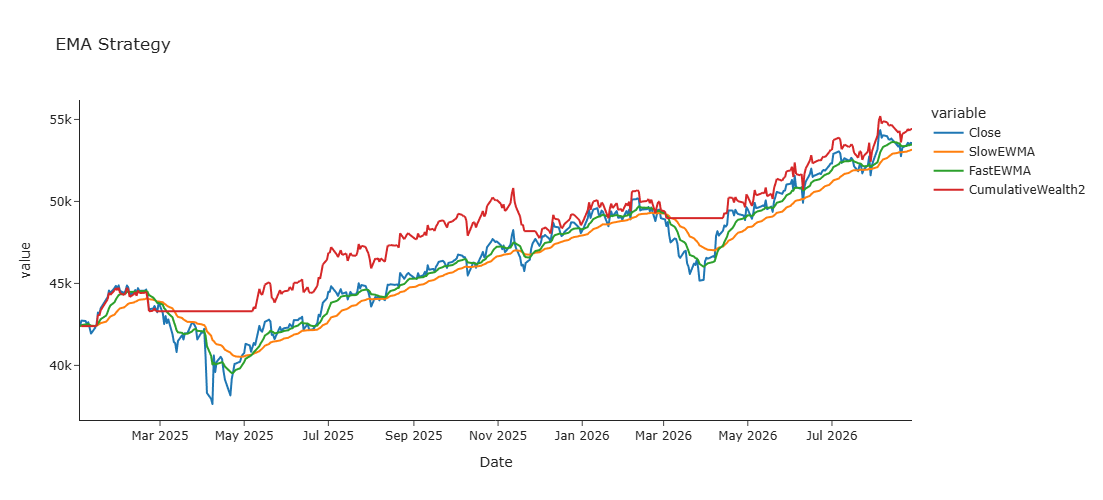

In [19]:
df2['CumulativeReturns2'] = df2['AlgoReturns2'].cumsum().shift(1)
df2['CumulativeWealth2'] = df2.iloc[0]['Close'] * np.exp(df2['CumulativeReturns2'])

fig = px.line(df2, x = df2.index, y = ['Close', 'SlowEWMA', 'FastEWMA', 'CumulativeWealth2'],
             height = 500, width = 1000, template = 'simple_white', title = 'EMA Strategy')
fig.show()

# Trend Following Strategy Using Bollinger Bands (EMA)

<br>
<div class="alert alert-block alert-info"><b>
Next we will still use a Trend Following approach but we will use a technical indicator as part of our strategy. Bollinger Bands
are a technical analysis tool used in finance, they create an upper and lower band which are both 2 standard deviations away from
the Moving Average. As we will see, it encapsulates the Moving Average and Close price between the Bands - this strategy is good
for reducing risk and offers a slightly different approach.
</b></div>
</br>

In [20]:
df3 = df2[['Close', 'SlowEWMA']].copy()

df3['UpperBand'] = df3['SlowEWMA'] + (2 * df3['Close'].rolling(30).std())
df3['LowerBand'] = df3['SlowEWMA'] - (2 * df3['Close'].rolling(30).std())
df3.iloc[80:].head(10)

,Close,SlowEWMA,UpperBand,LowerBand
Date,,,,
2025-04-30 00:00:00-04:00,40669.359375,40533.495665,43455.957206,37611.034125
2025-05-01 00:00:00-04:00,40752.960938,40547.654715,43422.932565,37672.376866
2025-05-02 00:00:00-04:00,41317.429688,40597.317617,43438.046168,37756.589065
2025-05-05 00:00:00-04:00,41218.828125,40637.415069,43436.304285,37838.525853
2025-05-06 00:00:00-04:00,40829.000000,40649.775387,43337.349243,37962.201531
2025-05-07 00:00:00-04:00,41113.968750,40679.723346,43254.493177,38104.953514
2025-05-08 00:00:00-04:00,41368.449219,40724.157273,43206.248114,38242.066432
2025-05-09 00:00:00-04:00,41249.378906,40758.042540,43153.256439,38362.828641
2025-05-12 00:00:00-04:00,42410.101562,40864.626993,43338.877326,38390.376659


In [21]:
df3['Signal3'] = 0
df3.loc[df3['Close'] <= df3['LowerBand'], 'Signal3'] = 1
df3.loc[df3['Close'] >= df3['UpperBand'], 'Signal3'] = -1
df3.iloc[40:].head(10)

,Close,SlowEWMA,UpperBand,LowerBand,Signal3
Date,,,,,
2025-03-04 00:00:00-05:00,42520.988281,43763.861611,44971.928472,42555.794749,1
2025-03-05 00:00:00-05:00,43006.589844,43715.005368,45000.387268,42429.623467,0
2025-03-06 00:00:00-05:00,42579.078125,43641.719739,45054.630445,42228.809033,0
2025-03-07 00:00:00-05:00,42801.718750,43587.526127,45070.892620,42104.159634,0
2025-03-10 00:00:00-04:00,41911.710938,43479.409018,45152.424155,41806.393881,0
2025-03-11 00:00:00-04:00,41433.480469,43347.413628,45239.121215,41455.706040,1
2025-03-12 00:00:00-04:00,41350.929688,43218.608212,45286.218502,41150.997922,0
2025-03-13 00:00:00-04:00,40813.570312,43063.444477,45361.523470,40765.365483,0
2025-03-14 00:00:00-04:00,41488.191406,42961.815246,45338.413232,40585.217260,0


In [22]:
df3['LogReturns3'] = np.log(df3['Close']).diff().shift(-1)
df3['StrategyReturns'] = df3['Signal3'] * df3['LogReturns3']

df3['CumulativeReturns3'] = (df3['StrategyReturns'].cumsum())
df3['CumulativeWealth3'] = df3.iloc[0]['Close'] * np.exp(df3['CumulativeReturns3'])
df3.head()

,Close,SlowEWMA,UpperBand,LowerBand,Signal3,LogReturns3,StrategyReturns,CumulativeReturns3,CumulativeWealth3
Date,,,,,,,,,
2025-01-02 00:00:00-05:00,42392.269531,42392.269531,NaN,NaN,0,0.007985,0.0,0.0,42392.269531
2025-01-03 00:00:00-05:00,42732.128906,42414.195943,NaN,NaN,0,-0.000599,-0.0,0.0,42392.269531
2025-01-06 00:00:00-05:00,42706.558594,42433.058049,NaN,NaN,0,-0.004181,-0.0,0.0,42392.269531
2025-01-07 00:00:00-05:00,42528.359375,42439.206522,NaN,NaN,0,0.002509,0.0,0.0,42392.269531
2025-01-08 00:00:00-05:00,42635.199219,42451.851212,NaN,NaN,0,-0.016477,-0.0,0.0,42392.269531


In [23]:
filtered = df3[df3['Signal3'] != 0]
filtered.head()

,Close,SlowEWMA,UpperBand,LowerBand,Signal3,LogReturns3,StrategyReturns,CumulativeReturns3,CumulativeWealth3
Date,,,,,,,,,
2025-03-04 00:00:00-05:00,42520.988281,43763.861611,44971.928472,42555.794749,1,0.011356,0.011356,0.011356,42876.401090
2025-03-11 00:00:00-04:00,41433.480469,43347.413628,45239.121215,41455.706040,1,-0.001994,-0.001994,0.009361,42790.975478
2025-04-03 00:00:00-04:00,40545.929688,42336.616929,44008.218455,40665.015404,1,-0.056598,-0.056598,-0.047236,40436.369830
2025-04-04 00:00:00-04:00,38314.859375,42077.148700,44250.375693,39903.921708,1,-0.009157,-0.009157,-0.056394,40067.773461
2025-04-07 00:00:00-04:00,37965.601562,41811.887594,44413.304002,39210.471187,1,-0.008465,-0.008465,-0.064858,39730.042554


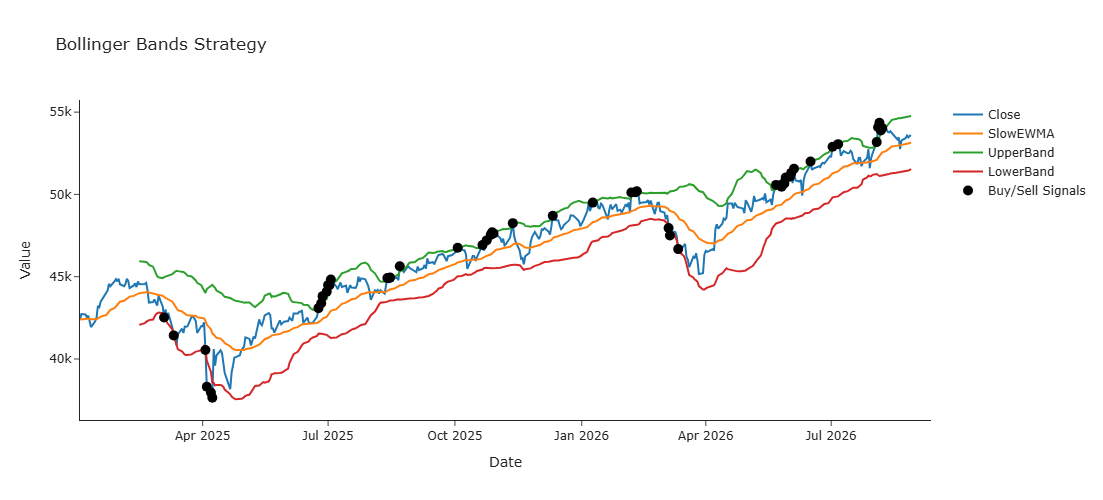

In [24]:
fig = go.Figure()
fig.add_trace(go.Scatter(x = df3.index, y = df3['Close'], name = 'Close'))
fig.add_trace(go.Scatter(x = df3.index, y = df3['SlowEWMA'], name = 'SlowEWMA'))
fig.add_trace(go.Scatter(x = df3.index, y = df3['UpperBand'], name = 'UpperBand'))
fig.add_trace(go.Scatter(x = df3.index, y = df3['LowerBand'], name = 'LowerBand'))
fig.add_trace(go.Scatter(x = filtered['Signal3'].index, y = filtered['Close'], 
              mode = 'markers', name = 'Buy/Sell Signals', marker = dict(size = 10, color = 'black')))

fig.update_layout(height = 500, width = 1000, template = 'simple_white',
                  title = dict(text = 'Bollinger Bands Strategy'), xaxis = dict(title = dict(text = 'Date')), 
                  yaxis = dict(title = dict(text = 'Value')))
fig.show()

<br>
<div class="alert alert-block alert-info"><b>
In the plot above we can see the Bollinger Bands encapsulating the Close and Moving Average time series, we also generate
Buy and Sell signals with black points/dots. The Buy signal is when the Close price touches or crosses the lower Bollinger
Band and a Sell signal is when the Close price touches/crosses the upper Bollinger Band. As we can see from this plot alone,
the strategy focuses more on reducing risk and therefore should not yield high returns. The wider the Bands are from each other,
signifies higher volatility or risk and the closer they are would be less risk - we can see that most of the Buy and Sell signals
occur when the bands are closer together and during high volatility no/less signals occur.
</b></div>
</br>

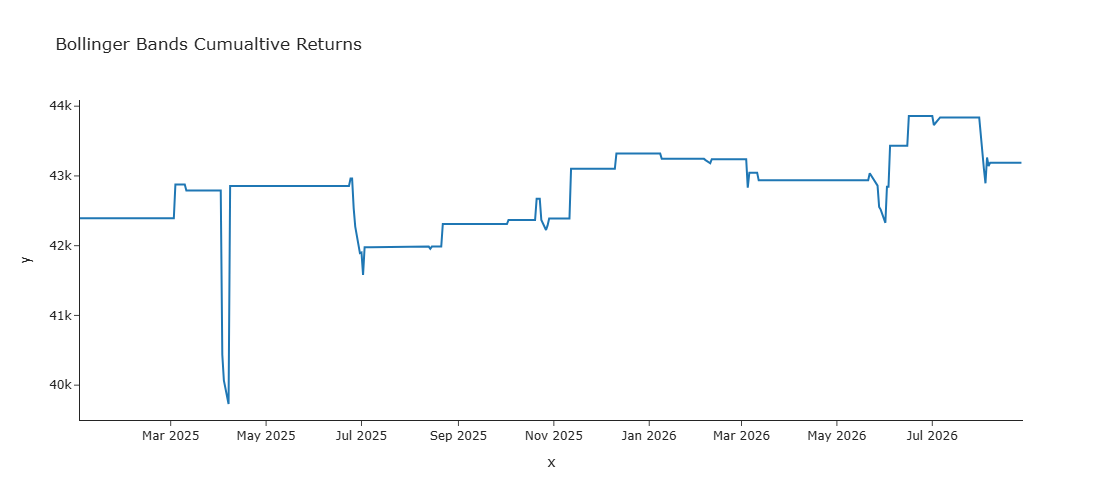

In [25]:
fig = px.line(x = df3.index, y = df3['CumulativeWealth3'],
             height = 500, width = 1000, template = 'simple_white', title = 'Bollinger Bands Cumualtive Returns')
fig.show()

<br>
<div class="alert alert-block alert-info"><b>
In the plot above we can see the Cumulative Returns over the time frame, where we can clearly see the fluctuations of the
strategy. We can see a steady trend from May 2025 onwards - which is after the huge frop in price during April of the same
year.
<br></br>
In the code cells below we can see that the Standard Deviation (Risk/Volatility) of this strategy is less compared to the
Buy-and-Hold, SMA and EMA strategies. We also observe that the Sharpe Ratio is a negative value, which means there are no excess
returns, and in general the returns from this strategy is not high compared to the others explored earlier. This makes sense as these
bands are used to reduce risk/volatility. It would be up to the individual to decide which strategy to use based on their expectations
and how much risk they would like to incur. These are basic strategies and there are more advanced and powerful methods using deep learning
that could also be explored.
</b></div>
</br>

In [26]:
print('Standard Deviation:', df3['StrategyReturns'].std())
print('Sharpe Ratio:', (df3['StrategyReturns'].mean() - risk_free_rate) / df3['StrategyReturns'].std())

Standard Deviation: 0.005194991016270551
Sharpe Ratio: -0.024169448504816855


In [27]:
print('Standard Deviation:', df3['LogReturns3'].std())
print('Sharpe Ratio:', (df3['LogReturns3'].mean() - risk_free_rate) / df3['LogReturns3'].std())

Standard Deviation: 0.009722045872177771
Sharpe Ratio: 0.04054568492944811
